In [1]:
# ============================================================
# SMART BUILDING ENERGY CONSUMPTION PREDICTION
# Machine Learning Implementation
# ============================================================


# Import pandas for loading and manipulating datasets
import pandas as pd

# Import numpy for numerical operations
import numpy as np


# Visualization library
import matplotlib.pyplot as plt


# Google Colab file upload tool
from google.colab import files


# Machine learning utilities
from sklearn.model_selection import train_test_split


# Regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


# Model evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
# ============================================================
# DATA ACQUISITION
# Upload smart building energy dataset
# ============================================================


# Upload CSV file from local computer
uploaded = files.upload()

Saving Energy data.csv to Energy data.csv


In [4]:
# ============================================================
# LOAD DATASET
# ============================================================


# Convert CSV file into pandas dataframe
data = pd.read_csv("Energy data.csv")


# Display first five rows
data.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,1/11/2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,1/11/2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,1/11/2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,1/11/2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,1/11/2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [5]:
# ============================================================
# DATA EXPLORATION
# Check dataset size and information
# ============================================================


# Number of rows and columns
print(data.shape)


# Display column information
data.info()

(19735, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float

In [6]:
# ============================================================
# DATA PREPROCESSING
# Convert date column into datetime format
# ============================================================


# Convert string date into datetime object
# This allows extraction of time-based features

data['date'] = pd.to_datetime(data['date'])

In [7]:
# ============================================================
# FEATURE ENGINEERING
# Creating additional predictive information
# ============================================================


# Extract hour of the day
# Energy consumption changes depending on time

data['hour'] = data['date'].dt.hour


# Extract day information

data['day'] = data['date'].dt.day


# Extract month information

data['month'] = data['date'].dt.month



# Create lag features
# These represent previous energy usage


# Previous 10-minute consumption

data['lag1'] = data['Appliances'].shift(1)



# Previous 1-hour consumption
# Dataset interval is 10 minutes
# Therefore 6 samples = 60 minutes

data['lag6'] = data['Appliances'].shift(6)



# Remove rows without previous values

data.dropna(inplace=True)

In [8]:
# ============================================================
# DEFINE INPUT AND OUTPUT VARIABLES
# ============================================================


# Features used for prediction

X = data.drop(
    ['Appliances','date'],
    axis=1
)


# Target variable
# Appliance energy consumption

y = data['Appliances']

In [9]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================


# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# ============================================================
# MODEL 1: LINEAR REGRESSION
# Baseline model
# ============================================================


# Create model

lr_model = LinearRegression()


# Train model

lr_model.fit(
    X_train,
    y_train
)


# Predict energy consumption

lr_prediction = lr_model.predict(X_test)

In [11]:
# ============================================================
# MODEL 2: RANDOM FOREST REGRESSOR
# Ensemble learning method
# ============================================================


# Create Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)



# Train model

rf_model.fit(
    X_train,
    y_train
)



# Generate predictions

rf_prediction = rf_model.predict(X_test)

In [12]:
# ============================================================
# MODEL 3: GRADIENT BOOSTING REGRESSOR
# Advanced ensemble model
# ============================================================


# Create Gradient Boosting model

gb_model = GradientBoostingRegressor(
    random_state=42
)



# Train model

gb_model.fit(
    X_train,
    y_train
)



# Generate predictions

gb_prediction = gb_model.predict(X_test)

In [13]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================


def evaluate_model(name, actual, prediction):


    # Average prediction error

    mae = mean_absolute_error(
        actual,
        prediction
    )


    # Penalizes large errors

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            prediction
        )
    )


    # Percentage of variation explained

    r2 = r2_score(
        actual,
        prediction
    )


    print(name)

    print("MAE:", mae)

    print("RMSE:", rmse)

    print("R2:", r2)

    print("------------------------")

In [14]:
# ============================================================
# PERFORMANCE COMPARISON
# ============================================================


evaluate_model(
    "Linear Regression",
    y_test,
    lr_prediction
)



evaluate_model(
    "Random Forest",
    y_test,
    rf_prediction
)



evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_prediction
)

Linear Regression
MAE: 29.22858905315646
RMSE: 61.94594492768777
R2: 0.6049573439704123
------------------------
Random Forest
MAE: 29.94842878864673
RMSE: 63.562992858065655
R2: 0.5840636237339484
------------------------
Gradient Boosting
MAE: 27.812430631239824
RMSE: 60.90067137491819
R2: 0.6181767331742434
------------------------


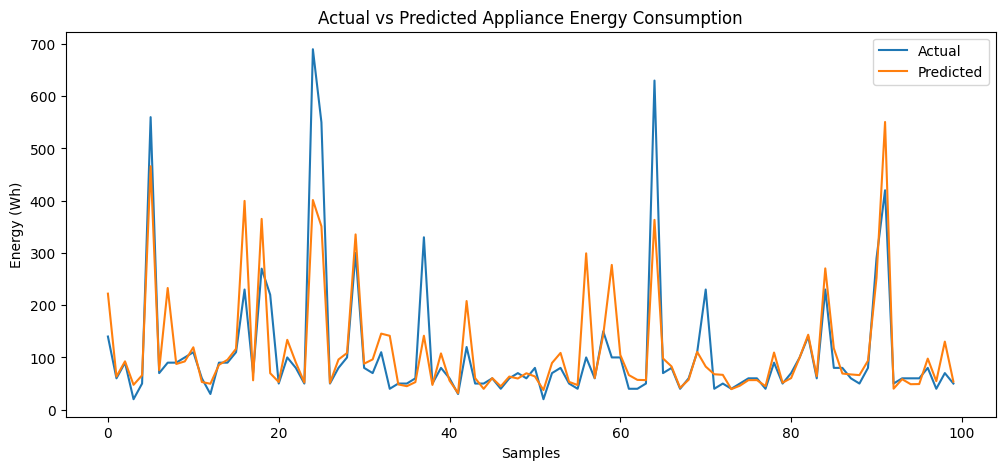

In [15]:
# ============================================================
# VISUAL MODEL ANALYSIS
# ============================================================


plt.figure(figsize=(12,5))


# Actual consumption

plt.plot(
    y_test.values[:100],
    label="Actual"
)



# Model prediction

plt.plot(
    rf_prediction[:100],
    label="Predicted"
)



plt.title(
    "Actual vs Predicted Appliance Energy Consumption"
)


plt.xlabel("Samples")

plt.ylabel("Energy (Wh)")


plt.legend()


plt.show()

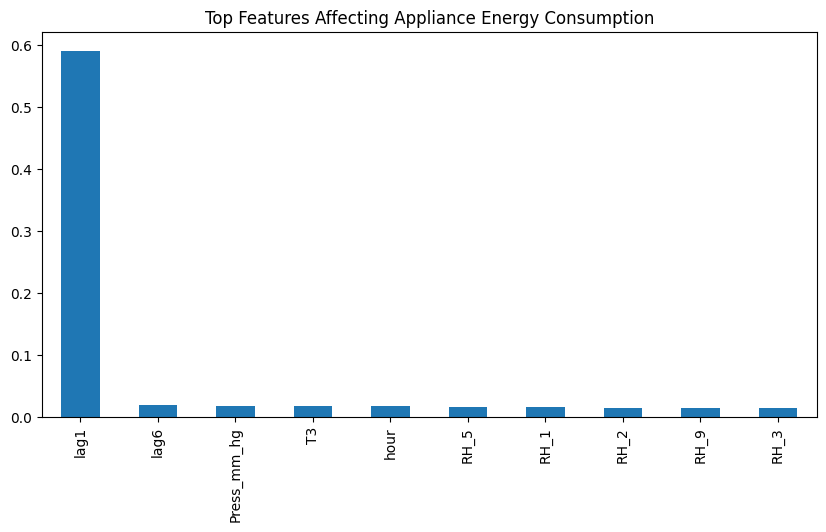

In [16]:
# ============================================================
# IDENTIFY IMPORTANT VARIABLES
# ============================================================


importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)



importance.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(10,5)
)



plt.title(
    "Top Features Affecting Appliance Energy Consumption"
)



plt.show()